# 读懂大模型的配置文件

> 现代 LLM 可以组合不同的 Attention、FFN、Norm 与位置编码，加载程序必须先知道采用了哪一种结构。一个权重文件里保存着 `[192, 576]` 的矩阵，程序却准备了 `[576, 576]` 的位置；参数数值虽然存在，结构对不上仍然无法运行。
>
> 权重只记录「已经学到的数值」，并不完整记录「这些数值应当放在哪里」。层数、宽度、Attention 头数等结构信息，需要由另一份文件说明。
>
> SmolLM2-135M 的 HuggingFace 仓库可以按四类文件来读：
>
> 1. **模型结构配置**：`config.json` 记录隐藏维度、层数、Attention 头数、FFN 宽度与 Norm 类型。
>
> 2. **`model.safetensors`** 保存训练后的参数值，每个参数的 shape 必须与模型结构对应。
>
> 3. **Tokenizer 配置**：词表、特殊 Token 与最大输入长度共同决定文本如何转换为 Token ID。
>
> 4. **`generation_config.json`** 保存生成阶段的默认值；temperature、top_p 等参数也可以在调用时指定。

SmolLM2-135M 的 `config.json` 中有三个与 Attention 直接相关的数字：

```text
hidden_size = 576
num_attention_heads = 9
num_key_value_heads = 3
```

每个 Attention 头的维度是 `576 ÷ 9 = 64`。Q 使用 9 个头，因此输出宽度是 `9 × 64 = 576`；K 和 V 各使用 3 个头，因此输出宽度是 `3 × 64 = 192`。K 投影矩阵的 shape 由此确定为 `[192, 576]`。

如果程序只看到 `hidden_size=576`，仍按照 9 个 K 头创建 `[576, 576]` 的矩阵，就无法加载权重文件中的 `[192, 576]`。数值没有缺失，出错的是模型结构。

`config.json` 中这组描述层数、宽度和组件形式的参数称为**模型配置（model config）**。加载模型时，程序先根据配置创建各层参数，再把权重文件中的数值放入对应位置。下面从这两个 K 投影矩阵开始，观察配置错误怎样变成一次 shape 冲突。

## 0. 模型结构与模型权重

这里只保留 K 投影这一处结构。两个 `Linear` 层都接收 576 维输入，一个输出 192 维，另一个输出 576 维；随后把同一份 K 权重分别放入两层，直接比较加载结果。

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

saved_k_weight = torch.randn(192, 576)
correct_k_proj = nn.Linear(576, 192, bias=False)
wrong_k_proj = nn.Linear(576, 576, bias=False)

print("权重文件中的 K 矩阵：", list(saved_k_weight.shape))
print("正确配置创建的参数：  	", list(correct_k_proj.weight.shape))
print("错误配置创建的参数：  	", list(wrong_k_proj.weight.shape))
print("\n关键观察：只有正确配置创建的 shape 能与已有权重逐项对应。")
assert saved_k_weight.shape == correct_k_proj.weight.shape
assert saved_k_weight.shape != wrong_k_proj.weight.shape


权重文件中的 K 矩阵： [192, 576]
正确配置创建的参数：  	 [192, 576]
错误配置创建的参数：  	 [576, 576]

关键观察：只有正确配置创建的 shape 能与已有权重逐项对应。


## 1. `config.json` 与模型结构

现在打开 [SmolLM2-135M 的 `config.json`](https://huggingface.co/HuggingFaceTB/SmolLM2-135M/blob/main/config.json)。文件里有二十多个字段，但不必逐行背诵。我们先寻找六个会直接改变参数 shape 的数字。

读取配置时，可以沿着模型的数据流提问：词表要创建多大的 Embedding？一个 token 用多少维表示？Attention 怎样拆头？FFN 中间要扩展到多宽？这样的顺序比记字段表更容易建立联系。

In [2]:
config = {
    "architectures": ["LlamaForCausalLM"],
    "hidden_size": 576,
    "intermediate_size": 1536,
    "num_attention_heads": 9,
    "num_key_value_heads": 3,
    "num_hidden_layers": 30,
    "vocab_size": 49152,
    "max_position_embeddings": 8192,
    "hidden_act": "silu",
    "rms_norm_eps": 1e-05,
    "rope_theta": 100000,
    "tie_word_embeddings": True,
    "attention_bias": False,
}

V, D, L, H, KV, FF = (config[k] for k in (
    "vocab_size", "hidden_size", "num_hidden_layers",
    "num_attention_heads", "num_key_value_heads", "intermediate_size"))
head_dim = D // H

assert D % H == 0, "hidden_size 必须能被 Attention 头数整除"
assert H % KV == 0, "Q 头数必须能被 KV 头数整除"

print(f"Embedding 矩阵：[{V}, {D}]")
print(f"每个 Attention 头：{D} ÷ {H} = {head_dim} 维")
print(f"每 {H // KV} 个 Q 头共享一组 K/V，共 {KV} 组")
print(f"每个 Block 的 FFN：{D} → {FF} → {D}")
print(f"模型一共堆叠 {L} 个 Block")


Embedding 矩阵：[49152, 576]
每个 Attention 头：576 ÷ 9 = 64 维
每 3 个 Q 头共享一组 K/V，共 3 组
每个 Block 的 FFN：576 → 1536 → 576
模型一共堆叠 30 个 Block


### 1.1 参数骨架

只看 JSON 仍然很抽象。我们先用这些数字创建一个 Block 的参数骨架：两层 RMSNorm、四个 Attention 投影和三个 SwiGLU 投影。

这里的前向传播为了核对 shape 与参数量而简化，没有加入 causal mask 和 RoPE。因此，它能说明参数放在哪里，但不是 SmolLM2 的完整复现。

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class TransformerBlock(nn.Module):
    """按配置创建用于核对 shape 的 Transformer Block 参数骨架。"""
    def __init__(self, config):
        super().__init__()
        d = config['hidden_size']
        ff = config['intermediate_size']
        h = config['num_attention_heads']
        kv = config['num_key_value_heads']
        hd = d // h
        bias = config['attention_bias']

        self.attn_norm = nn.RMSNorm(d, eps=config['rms_norm_eps'])
        self.ffn_norm  = nn.RMSNorm(d, eps=config['rms_norm_eps'])
        # Attention 四个投影
        self.q_proj = nn.Linear(d, h * hd, bias=bias)
        self.k_proj = nn.Linear(d, kv * hd, bias=bias)
        self.v_proj = nn.Linear(d, kv * hd, bias=bias)
        self.o_proj = nn.Linear(h * hd, d, bias=bias)
        # FFN 三个投影
        self.gate = nn.Linear(d, ff, bias=False)
        self.up   = nn.Linear(d, ff, bias=False)
        self.down = nn.Linear(ff, d, bias=False)

        self.n_heads = h
        self.n_kv_heads = kv
        self.head_dim = hd

    def forward(self, x):
        # Attention (简化版，不包含 causal mask 和 RoPE)
        residual = x
        x = self.attn_norm(x)
        B, T, D = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        # GQA 广播
        k = k.repeat_interleave(self.n_heads // self.n_kv_heads, dim=1)
        v = v.repeat_interleave(self.n_heads // self.n_kv_heads, dim=1)
        scale = self.head_dim ** -0.5
        attn = (q @ k.transpose(-2, -1)) * scale
        attn = F.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, D)
        x = residual + self.o_proj(out)
        # FFN
        residual = x
        x = self.ffn_norm(x)
        x = residual + self.down(F.silu(self.gate(x)) * self.up(x))
        return x

# 用 SmolLM2 的配置创建一个 Block 的参数骨架
block = TransformerBlock(config)
print("=== 单个 TransformerBlock 的参数骨架 ===")
print(block)
block_params = sum(p.numel() for p in block.parameters())
print(f"\n这个 Block 的参数量: {block_params:,}  ({block_params/1e6:.2f}M)")


=== 单个 TransformerBlock 的参数骨架 ===
TransformerBlock(
  (attn_norm): RMSNorm((576,), eps=1e-05, elementwise_affine=True)
  (ffn_norm): RMSNorm((576,), eps=1e-05, elementwise_affine=True)
  (q_proj): Linear(in_features=576, out_features=576, bias=False)
  (k_proj): Linear(in_features=576, out_features=192, bias=False)
  (v_proj): Linear(in_features=576, out_features=192, bias=False)
  (o_proj): Linear(in_features=576, out_features=576, bias=False)
  (gate): Linear(in_features=576, out_features=1536, bias=False)
  (up): Linear(in_features=576, out_features=1536, bias=False)
  (down): Linear(in_features=1536, out_features=576, bias=False)
)

这个 Block 的参数量: 3,540,096  (3.54M)


## 2. Q Head 与 K/V Head 的数量

如果沿用最熟悉的 Multi-Head Attention，9 个 Q 头应当配 9 个 K 头和 9 个 V 头。然而配置写的是 `num_attention_heads=9`、`num_key_value_heads=3`。若仍按 9 组 K/V 创建参数，就会回到开头的 shape 冲突。

所谓 **Grouped-Query Attention（GQA）**，就是让一组 K/V 头服务多个 Q 头。这里每个头是 $576 / 9 = 64$ 维，所以 Q 输出 $9 \times 64 = 576$ 维，K 和 V 各输出 $3 \times 64 = 192$ 维。先创建四个矩阵核对一次。

输入: [2, 16, 576]
Q 投影: [576, 576] → Q shape: [2, 9, 16, 64]
K 投影: [192, 576] → K shape: [2, 3, 16, 64]
V 投影: [192, 576] → V shape: [2, 3, 16, 64]
O 投影: [576, 576]

Q 参数: 331,776   K 参数: 110,592   K/Q = 0.33
如果是 MHA (Q=K=V=9): K 参数也会是 331,776
GQA 节省了 13,271,040 个 K+V 参数（30 层合计）


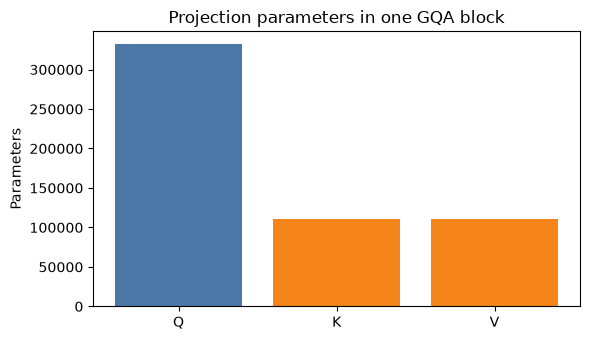

In [4]:
import torch
import torch.nn as nn

torch.manual_seed(42)

W_q = nn.Linear(D, H * head_dim, bias=False)
W_k = nn.Linear(D, KV * head_dim, bias=False)
W_v = nn.Linear(D, KV * head_dim, bias=False)
W_o = nn.Linear(H * head_dim, D, bias=False)

x = torch.randn(2, 16, D)  # 模拟 hidden states
q = W_q(x).view(2, 16, H, head_dim).transpose(1, 2)   # [2, 9, 16, 64]
k = W_k(x).view(2, 16, KV, head_dim).transpose(1, 2)  # [2, 3, 16, 64]
v = W_v(x).view(2, 16, KV, head_dim).transpose(1, 2)  # [2, 3, 16, 64]

print(f"输入: [2, 16, {D}]")
print(f"Q 投影: {list(W_q.weight.shape)} → Q shape: {list(q.shape)}")
print(f"K 投影: {list(W_k.weight.shape)} → K shape: {list(k.shape)}")
print(f"V 投影: {list(W_v.weight.shape)} → V shape: {list(v.shape)}")
print(f"O 投影: {list(W_o.weight.shape)}")
print()
q_p = sum(p.numel() for p in W_q.parameters())
k_p = sum(p.numel() for p in W_k.parameters())
print(f"Q 参数: {q_p:,}   K 参数: {k_p:,}   K/Q = {k_p/q_p:.2f}")
print(f"如果是 MHA (Q=K=V=9): K 参数也会是 {q_p:,}")
saved_kv_params = 2 * (q_p - k_p) * L
print(f"GQA 节省了 {saved_kv_params:,.0f} 个 K+V 参数（{L} 层合计）")

plt.figure(figsize=(6, 3.5))
plt.bar(["Q", "K", "V"], [q_p, k_p, k_p],
        color=["#4C78A8", "#F58518", "#F58518"])
plt.ylabel("Parameters")
plt.title("Projection parameters in one GQA block")
plt.tight_layout()
plt.show()


参数变少以后，9 个 Q 头怎样和 3 个 K/V 头做 Attention？实现时可以把每组 K/V 在逻辑上重复 3 次，使头数从 3 对齐到 9。

这一步的重点不是复制数据，而是看清共享关系：`KV[0]` 服务 `Q[0:3]`，`KV[1]` 服务 `Q[3:6]`，`KV[2]` 服务 `Q[6:9]`。

In [5]:
groups = H // KV  # 每组 3 个 Q 头
k_repeated = k.repeat_interleave(groups, dim=1)  # [2, 3, 16, 64] → [2, 9, 16, 64]
v_repeated = v.repeat_interleave(groups, dim=1)

# 现在 Q 和 K 头数一致了，可以正常做 Attention
scale = head_dim ** -0.5
attn_weights = (q @ k_repeated.transpose(-2, -1)) * scale  # [2, 9, 16, 16]

print("K 原始形状：", list(k.shape), "→ 重复后：", list(k_repeated.shape))
print("V 原始形状：", list(v.shape), "→ 重复后：", list(v_repeated.shape))
print(f"QK^T 结果:   {list(attn_weights.shape)}")
print(f"\n分组关系:")
for kv_idx in range(KV):
    q_idx = list(range(kv_idx * groups, (kv_idx + 1) * groups))
    print(f"  KV[{kv_idx}] → Q{q_idx}")

K 原始形状： [2, 3, 16, 64] → 重复后： [2, 9, 16, 64]
V 原始形状： [2, 3, 16, 64] → 重复后： [2, 9, 16, 64]
QK^T 结果:   [2, 9, 16, 16]

分组关系:
  KV[0] → Q[0, 1, 2]
  KV[1] → Q[3, 4, 5]
  KV[2] → Q[6, 7, 8]


## 3. `intermediate_size`

在基础 Transformer 中，我们曾把 FFN 写成两次线性变换：先从 $d$ 扩展到 $4d$，再缩回 $d$。照此推算，`hidden_size=576` 时中间宽度应当是 2304。配置却写着 `intermediate_size=1536`。

原因是这里使用 **SwiGLU FFN**。它不再只有 up 和 down 两个矩阵，而是加入 gate、up、down 三个矩阵：

```text
  x → up_proj   ┐
  x → gate_proj ├→ SiLU(gate) * up → down_proj → out
```

如果仍把中间宽度设成 $4d$，三个矩阵会显著增加参数量。SmolLM2 选择较窄的 1536 维，使门控结构的总参数量保持在合适范围。下面创建这三个矩阵，并验证输入与输出仍然都是 576 维。

In [6]:
import torch.nn as nn
import torch.nn.functional as F

import torch

class LlamaFFN(nn.Module):
    """Llama 风格的 SwiGLU FFN：gate 做门控，up 做投影，down 收回来"""
    def __init__(self, dim, intermediate_dim):
        super().__init__()
        self.gate = nn.Linear(dim, intermediate_dim, bias=False)
        self.up   = nn.Linear(dim, intermediate_dim, bias=False)
        self.down = nn.Linear(intermediate_dim, dim, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))

ffn = LlamaFFN(D, FF)
x = torch.randn(2, 16, D)
out = ffn(x)

gate_p = sum(p.numel() for p in ffn.gate.parameters())
up_p   = sum(p.numel() for p in ffn.up.parameters())
down_p = sum(p.numel() for p in ffn.down.parameters())

print(f"LlamaFFN 结构:")
print(f"  gate: {list(ffn.gate.weight.shape)}  ({gate_p:,} params)")
print(f"  up:   {list(ffn.up.weight.shape)}  ({up_p:,} params)")
print(f"  down: {list(ffn.down.weight.shape)}  ({down_p:,} params)")
print(f"  合计: {gate_p + up_p + down_p:,} params")
print(f"\n前向：输入 [2, 16, {D}]，中间 [2, 16, {FF}]，输出 [2, 16, {D}]")
print(f"输入 shape: {list(x.shape)}  输出 shape: {list(out.shape)}")
print("关键观察：SwiGLU 使用 gate、up、down 三个矩阵。")


LlamaFFN 结构:
  gate: [1536, 576]  (884,736 params)
  up:   [1536, 576]  (884,736 params)
  down: [576, 1536]  (884,736 params)
  合计: 2,654,208 params

前向：输入 [2, 16, 576]，中间 [2, 16, 1536]，输出 [2, 16, 576]
输入 shape: [2, 16, 576]  输出 shape: [2, 16, 576]
关键观察：SwiGLU 使用 gate、up、down 三个矩阵。


## 4. 配置与权重兼容性

配置中的 `rms_norm_eps=1e-5` 看起来不像层数和宽度那样醒目，但它同样参与计算。所谓 **RMSNorm**，就是用均方根调整向量尺度，而不先减去均值。通俗地说，它只关心一组数字整体有多大，不把中心强制移动到 0。

LayerNorm 通常有 weight 和 bias 两组参数；这里的 RMSNorm 只有 weight。若误建成 LayerNorm，模型中就会多出权重文件里不存在的 bias。我们用同一份输入比较两者。

In [7]:
# 直接用 PyTorch 内置的 RMSNorm 和 LayerNorm
import torch
import torch.nn as nn

rn = nn.RMSNorm(D, eps=config['rms_norm_eps'])
ln = nn.LayerNorm(D, eps=config['rms_norm_eps'])

print("=== nn.RMSNorm 结构 ===")
print(rn)
print("\n=== nn.LayerNorm 结构 ===")
print(ln)

# 同一份随机输入
x = torch.randn(4, 8, D)
with torch.no_grad():
    ln_out = ln(x)
    rn_out = rn(x)

print(f"\nLayerNorm:  weight + bias = {sum(p.numel() for p in ln.parameters())} 个参数")
print(f"RMSNorm:   只有 weight    = {sum(p.numel() for p in rn.parameters())} 个参数")
print(f"\n归一化前:  mean={x.mean():.3f}, std={x.std():.3f}")
print(f"LayerNorm: mean={ln_out.mean():.6f}, std={ln_out.std():.3f}  ← 均值为 0")
print(f"RMSNorm:   mean={rn_out.mean():.4f}, std={rn_out.std():.3f}  ← 均值不为 0")
print(f"\n每层省 {D} 个 bias 参数，30 层合计省 {D * 30:,} 个")


=== nn.RMSNorm 结构 ===
RMSNorm((576,), eps=1e-05, elementwise_affine=True)

=== nn.LayerNorm 结构 ===
LayerNorm((576,), eps=1e-05, elementwise_affine=True, bias=True)

LayerNorm:  weight + bias = 1152 个参数
RMSNorm:   只有 weight    = 576 个参数

归一化前:  mean=0.012, std=1.001
LayerNorm: mean=0.000000, std=1.000  ← 均值为 0
RMSNorm:   mean=0.0115, std=1.000  ← 均值不为 0

每层省 576 个 bias 参数，30 层合计省 17,280 个


## 5. 参数量计算

到这里，我们已经从配置恢复了主要参数 shape。现在做一次总检查：先用公式逐项计算，再让 PyTorch 对参数骨架调用 `sum(p.numel())`。如果两种结果不同，说明至少有一个字段还没有正确映射。

`tie_word_embeddings=True` 也在这里发挥作用：输出层复用输入 Embedding 的权重，不再单独增加一个 `[49152, 576]` 的矩阵。

In [8]:
# ========== 理论计算：逐项按公式算 ==========
# 每层 Attention: Q, K, V, O 四个投影
import torch.nn as nn
import torch.nn.functional as F

q_p  = D * H * head_dim       # Q: [D, H*head_dim]
k_p  = D * KV * head_dim      # K: [D, KV*head_dim]
v_p  = D * KV * head_dim      # V: [D, KV*head_dim]
o_p  = H * head_dim * D       # O: [H*head_dim, D]
attn_p = q_p + k_p + v_p + o_p

# 每层 FFN: gate, up, down 三个投影
ffn_p = 3 * D * FF

# 每层 Norm: 2 个 RMSNorm，每个只有 D 个 weight
norm_p = 2 * D

per_layer = attn_p + ffn_p + norm_p
total_theory = V * D + L * per_layer + D  # Embedding + 30层 + 最终Norm

print("========== 理论计算（公式） ==========")
print(f"每层 Attention (Q+K+V+O): {attn_p:>10,}")
print(f"每层 FFN (gate+up+down):   {ffn_p:>10,}")
print(f"每层 RMSNorm × 2:          {norm_p:>10,}")
print(f"每层小计:                  {per_layer:>10,} ≈ {per_layer/1e6:.2f}M")
print(f"\nEmbedding ({V}×{D}):       {V*D:>10,} ≈ {V*D/1e6:.1f}M")
print(f"{L} 层 Block:              {L*per_layer:>10,} ≈ {L*per_layer/1e6:.1f}M")
print(f"最终 RMSNorm:              {D:>10,}")
print(f"理论总计:                  {total_theory:>10,} ≈ {total_theory/1e6:.1f}M")

# ========== 真实计算：建出参数骨架，用 sum(p.numel()) 算 ==========
class SmolLM2ConfigModel(nn.Module):
    """用 config 组装 SmolLM2：Embedding → 30×Block → RMSNorm → 输出投影"""
    def __init__(self, config):
        super().__init__()
        d, V = config['hidden_size'], config['vocab_size']
        self.embed = nn.Embedding(V, d)
        self.blocks = nn.ModuleList(
            [TransformerBlock(config) for _ in range(config['num_hidden_layers'])])
        self.final_norm = nn.RMSNorm(d, eps=config['rms_norm_eps'])

    def forward(self, x):
        x = self.embed(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.final_norm(x)
        # tie_word_embeddings=True：输出投影复用 embed.weight，不另建 lm_head
        return F.linear(x, self.embed.weight)

model = SmolLM2ConfigModel(config)
total_real = sum(p.numel() for p in model.parameters())

print("\n========== 真实计算 (sum(p.numel())) ==========")
emb_real = sum(p.numel() for p in model.embed.parameters())
blocks_real = sum(p.numel() for p in model.blocks.parameters())
norm_real = sum(p.numel() for p in model.final_norm.parameters())
print(f"Embedding:     {emb_real:>10,}  ({V}×{D})")
print(f"30×Block:      {blocks_real:>10,}  ({L}×{per_layer:,})")
print(f"final_norm:    {norm_real:>10,}  ({D})")
print(f"{'─'*45}")
print(f"真实总计:      {total_real:>10,} ≈ {total_real/1e6:.1f}M")

print(f"\n========== 对照 ==========")
print(f"理论计算: {total_theory:,}")
print(f"真实计算: {total_real:,}")
print(f"两者一致: {total_theory == total_real}")
if total_theory == total_real:
    print("✓ 理论公式和 PyTorch 实际参数完全对上了")
else:
    print(f"✗ 差 {abs(total_theory - total_real):,}，请检查")


========== 理论计算（公式） ==========
每层 Attention (Q+K+V+O):    884,736
每层 FFN (gate+up+down):    2,654,208
每层 RMSNorm × 2:               1,152
每层小计:                   3,540,096 ≈ 3.54M

Embedding (49152×576):       28,311,552 ≈ 28.3M
30 层 Block:              106,202,880 ≈ 106.2M
最终 RMSNorm:                     576
理论总计:                  134,515,008 ≈ 134.5M



========== 真实计算 (sum(p.numel())) ==========
Embedding:     28,311,552  (49152×576)
30×Block:      106,202,880  (30×3,540,096)
final_norm:           576  (576)
─────────────────────────────────────────────
真实总计:      134,515,008 ≈ 134.5M

========== 对照 ==========
理论计算: 134,515,008
真实计算: 134,515,008
两者一致: True
✓ 理论公式和 PyTorch 实际参数完全对上了


总数对上以后，还可以继续问：参数主要分配给了哪里？饼图会显示，RMSNorm 的参数占比很小，主要部分是 30 个 FFN 与 Embedding。

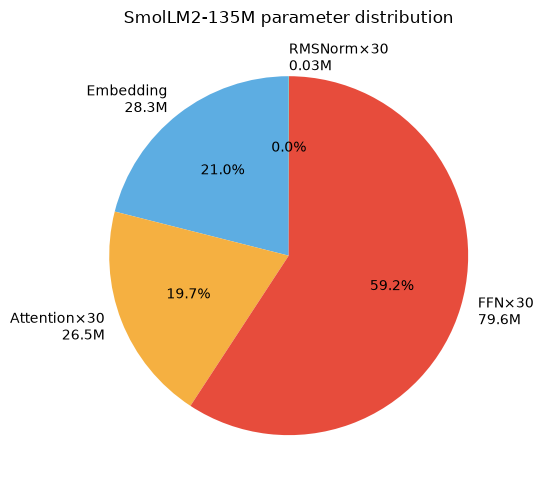

In [9]:
import matplotlib.pyplot as plt

emb_s = V * D
attn_s = attn_p * L
ffn_s = ffn_p * L
norm_s = norm_p * L

labels = [f'Embedding\n{emb_s/1e6:.1f}M', f'Attention×{L}\n{attn_s/1e6:.1f}M',
          f'FFN×{L}\n{ffn_s/1e6:.1f}M', f'RMSNorm×{L}\n{norm_s/1e6:.2f}M']
sizes = [emb_s, attn_s, ffn_s, norm_s]

plt.figure(figsize=(6, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=['#5DADE2','#F5B041','#E74C3C','#58D68D'])
plt.title(f'SmolLM2-135M parameter distribution')
plt.tight_layout()
plt.show()

## 6. 三类模型配置

参数总数已经核对完成，但模型还不能直接接收文字。`config.json` 只描述模型内部结构；文字怎样切成 Token，要看 Tokenizer 的词表、合并规则和特殊 Token 配置。

SmolLM2-135M 的真实 `tokenizer_config.json` 也提醒我们：不存在的字段不能凭经验补上。这个文件把 `<|endoftext|>` 同时指定为 BOS、EOS 和未知 Token，却没有指定 pad Token，也没有 `add_bos_token=True` 之类的开关。

In [10]:
tokenizer_config = {
    "bos_token": "<|endoftext|>",
    "eos_token": "<|endoftext|>",
    "unk_token": "<|endoftext|>",
    "model_max_length": 8192,
    "tokenizer_class": "GPT2Tokenizer",
    "vocab_size": 49152,
}

print("SmolLM2 tokenizer_config.json（节选）：")
print(json.dumps(tokenizer_config, indent=2, ensure_ascii=False))


SmolLM2 tokenizer_config.json（节选）：
{
  "bos_token": "<|endoftext|>",
  "eos_token": "<|endoftext|>",
  "unk_token": "<|endoftext|>",
  "model_max_length": 8192,
  "tokenizer_class": "GPT2Tokenizer",
  "vocab_size": 49152
}


模型与 Tokenizer 的连接处只有一个简单约束：Tokenizer 输出的每个 ID，都必须落在 Embedding 的行号范围内。

真实词表中，`<|endoftext|>` 的 ID 是 0，`<|im_start|>` 是 1，`<|im_end|>` 是 2。下面用一小段 Token ID 检查这个接口。

In [11]:
special_token_ids = {
    "<|endoftext|>": 0,
    "<|im_start|>": 1,
    "<|im_end|>": 2,
}
token_ids = [0, 1847, 302, 2]

print("特殊 Token 到 ID 的映射：", special_token_ids)
print("一次编码结果：", token_ids)
print(f"Embedding 可接受的 ID 范围：0 到 {V - 1}")
assert min(token_ids) >= 0 and max(token_ids) < V
print("关键观察：这些 ID 都能定位到 Embedding 的某一行。")


特殊 Token 到 ID 的映射： {'<|endoftext|>': 0, '<|im_start|>': 1, '<|im_end|>': 2}
一次编码结果： [0, 1847, 302, 2]
Embedding 可接受的 ID 范围：0 到 49151
关键观察：这些 ID 都能定位到 Embedding 的某一行。


In [12]:
required_behavior_fields = ["pad_token", "padding_side", "add_bos_token"]
missing_fields = [key for key in required_behavior_fields if key not in tokenizer_config]

print("在该文件中没有找到：", missing_fields)
print("关键观察：缺少字段不等于 True，也不等于某个约定值。")
print("调用代码若需要 padding，必须明确指定策略或采用库的默认行为。")


在该文件中没有找到： ['pad_token', 'padding_side', 'add_bos_token']
关键观察：缺少字段不等于 True，也不等于某个约定值。
调用代码若需要 padding，必须明确指定策略或采用库的默认行为。


### 6.1 默认配置与请求参数

模型输出 logits 后，还要决定怎样选择下一个 Token。这一步属于生成策略，不改变模型权重的 shape。

SmolLM2-135M 仓库中的真实 `generation_config.json` 只有 BOS、EOS 和 Transformers 版本，并没有 `temperature=0.6`、`top_p=0.9` 或 `top_k=50`。这些值可以由一次生成请求传入，但不能冒充仓库默认值。

In [13]:
generation_config = {
    "_from_model_config": True,
    "bos_token_id": 0,
    "eos_token_id": 0,
    "transformers_version": "4.40.1",
}

request_config = {
    "temperature": 0.6,
    "top_p": 0.9,
    "top_k": 50,
    "max_new_tokens": 256,
    "do_sample": True,
}

print("仓库中的 generation_config.json：")
print(json.dumps(generation_config, indent=2, ensure_ascii=False))


仓库中的 generation_config.json：
{
  "_from_model_config": true,
  "bos_token_id": 0,
  "eos_token_id": 0,
  "transformers_version": "4.40.1"
}


#### 选读：请求参数与候选分布

下面的实验使用我们自己定义的 `request_config`，不是读取 SmolLM2 的仓库默认值。它只用于提前建立一个边界：结构配置决定模型怎样计算 logits，生成请求决定怎样从 logits 选择 Token。

先看 temperature。它在 softmax 之前缩放 logits。$T < 1$ 时分布更集中；$T > 1$ 时分布更平缓。生成一章还会从零实现完整采样过程，这里只观察概率图。

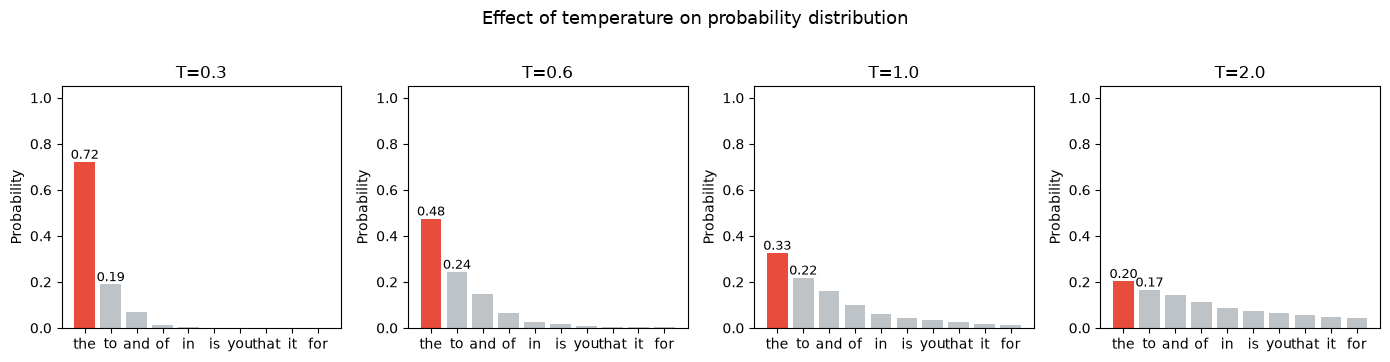

关键观察：T=0.3 时最高概率 token 几乎独占，T=2.0 时概率趋于均匀。
本次请求使用 T=0.6；这不是模型仓库的默认值。


In [14]:
import matplotlib.pyplot as plt
import numpy as np

import torch

tokens = ["the", "to", "and", "of", "in", "is", "you", "that", "it", "for"]
logits = torch.tensor([3.2, 2.8, 2.5, 2.0, 1.5, 1.2, 0.9, 0.6, 0.3, 0.1])

temperatures = [0.3, 0.6, 1.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, T in zip(axes, temperatures):
    probs = torch.softmax(logits / T, dim=-1).numpy()
    colors = ['#E74C3C' if p == probs.max() else '#BDC3C7' for p in probs]
    ax.bar(range(len(tokens)), probs, color=colors)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"T={T}")
    ax.set_ylabel("Probability")
    # 标注最高概率
    top2 = np.argsort(probs)[-2:]
    ax.annotate(f"{probs[top2[0]]:.2f}", (top2[0], probs[top2[0]]),
                ha='center', va='bottom', fontsize=9)
    ax.annotate(f"{probs[top2[1]]:.2f}", (top2[1], probs[top2[1]]),
                ha='center', va='bottom', fontsize=9)

plt.suptitle("Effect of temperature on probability distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("关键观察：T=0.3 时最高概率 token 几乎独占，T=2.0 时概率趋于均匀。")
request_temperature = request_config["temperature"]
print(f"本次请求使用 T={request_temperature}；这不是模型仓库的默认值。")


`top_p` 保留什么？

把 Token 按概率从高到低排列，再选择累积概率达到 $p$ 的最小集合。这称为 nucleus sampling。概率集中时集合较小，概率平缓时集合较大。

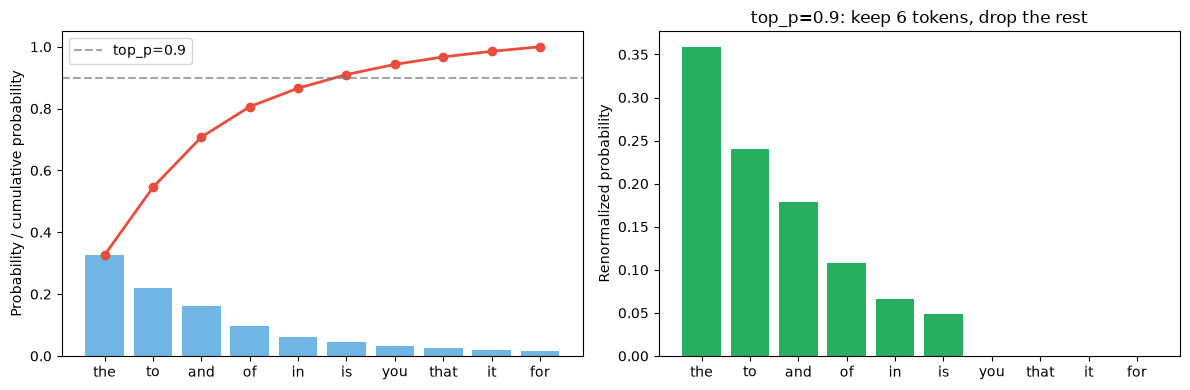

top_p=0.9：保留了前 6 个 Token：['the', 'to', 'and', 'of', 'in', 'is']
被丢弃的 token: ['you', 'that', 'it', 'for']


In [15]:
import torch
import matplotlib.pyplot as plt

probs = torch.softmax(logits, dim=-1)
sorted_probs, sorted_indices = torch.sort(probs, descending=True)
cumsum = torch.cumsum(sorted_probs, dim=-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 左图：累积概率
ax1.bar(range(len(tokens)), sorted_probs.numpy(), color='#3498DB', alpha=0.7)
ax1.plot(range(len(tokens)), cumsum.numpy(), 'o-', color='#E74C3C', linewidth=2, markersize=6)
ax1.axhline(y=0.9, color='gray', linestyle='--', alpha=0.7, label='top_p=0.9')
ax1.set_xticks(range(len(tokens)))
ax1.set_xticklabels([tokens[i] for i in sorted_indices])
ax1.set_ylabel("Probability / cumulative probability")
ax1.legend()

# 右图：top_p=0.9 后保留的 token
mask = cumsum <= 0.9
keep_n = mask.sum().item() + 1  # +1 是因为要包含第一个超过阈值的
keep_indices = sorted_indices[:keep_n]
keep_probs = probs[keep_indices]
filtered = torch.zeros_like(probs)
filtered[keep_indices] = keep_probs / keep_probs.sum()

ax2.bar(range(len(tokens)), filtered.numpy(),
        color=['#27AE60' if i in keep_indices else '#BDC3C7' for i in range(len(tokens))])
ax2.set_xticks(range(len(tokens)))
ax2.set_xticklabels(tokens)
ax2.set_ylabel("Renormalized probability")
ax2.set_title(f"top_p=0.9: keep {keep_n} tokens, drop the rest")

plt.tight_layout()
plt.show()

kept_tokens = [tokens[i] for i in sorted_indices[:keep_n]]
print(f"top_p=0.9：保留了前 {keep_n} 个 Token：{kept_tokens}")
print(f"被丢弃的 token: {[tokens[i] for i in sorted_indices[keep_n:]]}")


`top_k` 与 `top_p` 有什么不同？

`top_k` 固定保留概率最高的 $k$ 个 Token。它控制的是候选数量，而 `top_p` 控制的是候选集合覆盖的概率质量。下面仍使用玩具词表观察区别。

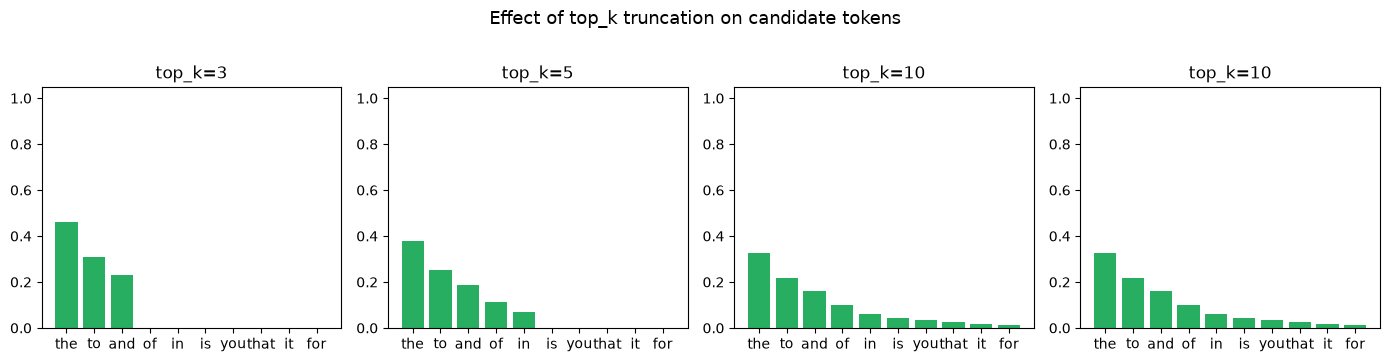

一次请求设置 top_k=50。
它会从 49,152 个 Token 中保留前 50 个。
候选数量占词表的 0.10%。


In [16]:
import torch
import matplotlib.pyplot as plt

K_list = [3, 5, 10, len(tokens)]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, K in zip(axes, K_list):
    topk_indices = sorted_indices[:K]
    topk_probs = probs[topk_indices]
    topk_probs = topk_probs / topk_probs.sum()
    display = torch.zeros_like(probs)
    display[topk_indices] = topk_probs
    colors = ['#27AE60' if i in topk_indices else '#BDC3C7' for i in range(len(tokens))]
    ax.bar(range(len(tokens)), display.numpy(), color=colors)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"top_k={K}")

plt.suptitle("Effect of top_k truncation on candidate tokens", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

request_top_k = request_config["top_k"]
print(f"一次请求设置 top_k={request_top_k}。")
print(f"它会从 {V:,} 个 Token 中保留前 {request_top_k} 个。")
print(f"候选数量占词表的 {request_top_k / V * 100:.2f}%。")


三个请求参数放在一起

实际生成时，temperature、`top_k` 与 `top_p` 可以共同作用。下面的教学函数先缩放 logits，再分别计算两种过滤条件，最后取交集。不同框架的处理顺序与边界细节可能不同，因此工程使用时应以对应版本的实现为准。

In [17]:
import torch

def sample_filter(all_tokens, logits, T=1.0, top_k=None, top_p=None):
    """应用 temperature、top_k、top_p 后返回保留的 token 列表"""
    scaled = logits / T
    probs = torch.softmax(scaled, dim=-1)
    allowed = torch.ones_like(probs, dtype=torch.bool)

    # top_k 不能超过词表大小
    k = min(top_k, len(all_tokens)) if top_k is not None else None
    if k is not None:
        topk_vals, _ = torch.topk(probs, k)
        threshold = topk_vals[-1]
        allowed = allowed & (probs >= threshold)

    if top_p is not None:
        sorted_p, sorted_i = torch.sort(probs, descending=True)
        cum = torch.cumsum(sorted_p, dim=-1)
        n_keep = min((cum <= top_p).sum().item() + 1, len(all_tokens))
        keep_i = sorted_i[:n_keep]
        mask = torch.zeros_like(probs, dtype=torch.bool)
        mask[keep_i] = True
        allowed = allowed & mask

    return [all_tokens[i] for i in range(len(all_tokens)) if allowed[i]]

# 三种配置（top_k 改为适合 demo 词表大小的值）
configs = [
    ("保守采样", 0.3, 3, 0.85),
    ("贪心 (T→0)", 0.001, None, None),
    ("创意模式", 1.2, None, 0.95),
]

logits_np = logits.clone()
print(f"{'配置':<20} {'保留 token'}")
print("-" * 50)
for name, T, tk, tp in configs:
    kept = sample_filter(tokens, logits_np, T=T, top_k=tk, top_p=tp)
    print(f"{name:<20} {kept}")

print("\n关键观察：在这个教学实现中，最终候选是两种过滤条件的交集。")
print("保守设置保留较少候选；较高 temperature 与 top_p 会保留更多候选。")


配置                   保留 token
--------------------------------------------------
保守采样                 ['the', 'to']
贪心 (T→0)             ['the', 'to', 'and', 'of', 'in', 'is', 'you', 'that', 'it', 'for']
创意模式                 ['the', 'to', 'and', 'of', 'in', 'is', 'you', 'that']

关键观察：在这个教学实现中，最终候选是两种过滤条件的交集。
保守设置保留较少候选；较高 temperature 与 top_p 会保留更多候选。


## 7. 推理请求的四个阶段

最后把整条路径串起来。注意第四阶段写的是「仓库默认值 + 本次请求参数」：调用方传入的值可以覆盖默认行为，因此不能只看仓库文件就断言一次请求采用了什么采样参数。

In [18]:
stages = [
    ("1. Text → Token IDs", "Tokenizer files", "vocabulary and special tokens"),
    ("2. Token IDs → model", "config.json", "shapes and architecture"),
    ("3. Model → logits", "model weights", "learned parameter values"),
    ("4. Logits → next Token", "generation defaults + request", "sampling policy"),
]

for stage, source, role in stages:
    print(f"{stage:<25} | {source:<29} | {role}")

print("\n关键观察：四个阶段可以分别修改，但接口必须保持一致。")
print("例如 Token ID 必须小于 vocab_size，参数 shape 必须匹配权重文件。")


1. Text → Token IDs       | Tokenizer files               | vocabulary and special tokens
2. Token IDs → model      | config.json                   | shapes and architecture
3. Model → logits         | model weights                 | learned parameter values
4. Logits → next Token    | generation defaults + request | sampling policy

关键观察：四个阶段可以分别修改，但接口必须保持一致。
例如 Token ID 必须小于 vocab_size，参数 shape 必须匹配权重文件。


## 小结

完成本章后，我们应当能够确认：

- [ ] 能解释为什么只有权重文件还不足以恢复模型
- [ ] 能从 `hidden_size` 与头数算出 `head_dim`，并检查整除关系
- [ ] 能说明 GQA 中 9 个 Q 头怎样共享 3 个 K/V 头
- [ ] 能从 Embedding、Attention、SwiGLU 与 RMSNorm 核算总参数量
- [ ] 能解释 `tie_word_embeddings=True` 为什么减少一块大矩阵
- [ ] 能分清模型结构、Tokenizer 行为、权重数值与生成请求的边界
- [ ] 不会把调用时传入的 sampling 参数写成模型仓库默认值

读一个陌生模型时，我们可以先抓住 shape：从 Embedding 进入 Block，依次检查 Attention、FFN 与 Norm，最后核对参数总数。其余文件承担不同职责，不应混成一张含糊的「模型说明书」。

## 作业

> 可以让 AI 帮忙解释思路，但不建议直接让 AI「做完这道题」。

**作业 1：从配置恢复 GQA 的分组关系**

根据 SmolLM2-135M 的 `hidden_size=576`、`num_attention_heads=9` 和 `num_key_value_heads=3`，计算每个头的维度，以及每组 K/V 服务多少个 Q 头。

小提示：先做两次整数除法，并检查有没有余数。

In [ ]:
# TODO：把 None 替换成计算式
exercise_head_dim = None
q_heads_per_kv_group = None

assert exercise_head_dim == 64, "请重新计算 576 ÷ 9"
assert q_heads_per_kv_group == 3, "请重新计算 9 ÷ 3"
print("作业 1 通过：已经能从配置恢复 GQA 的基本 shape。")


**作业 2：修改配置，同时守住 shape 约束**

把 `hidden_size` 改成 768，并选择 12 个 Q 头、4 个 K/V 头。先补全配置，再运行参数量核算。

小提示：新的 `head_dim` 仍应当是 64，每组 K/V 仍服务 3 个 Q 头。

In [ ]:
# 作业 2：补全三个 TODO，再观察参数量变化
my_config = {
    "vocab_size": 49152,
    "hidden_size": None,          # TODO: 768
    "num_hidden_layers": 30,
    "num_attention_heads": None, # TODO: 12
    "num_key_value_heads": None, # TODO: 4
    "intermediate_size": 2048,
}

V2, D2, L2, H2, KV2, FF2 = (my_config[k] for k in (
    "vocab_size", "hidden_size", "num_hidden_layers",
    "num_attention_heads", "num_key_value_heads", "intermediate_size"))
assert D2 == 768, "请填写 hidden_size"
assert H2 == 12, "请填写 num_attention_heads"
assert KV2 == 4, "请填写 num_key_value_heads"
assert D2 % H2 == 0 and H2 % KV2 == 0, "头数与维度必须满足整除关系"
hd2 = D2 // H2

emb_p = V2 * D2
attn_p = D2 * H2 * hd2 + D2 * KV2 * hd2 * 2 + H2 * hd2 * D2
ffn_p = 3 * D2 * FF2
per_layer_2 = attn_p + ffn_p + 2 * D2
total_p = emb_p + L2 * per_layer_2 + D2

assert hd2 == 64 and H2 // KV2 == 3
print(f"作业 2 通过：新配置约有 {total_p / 1e6:.1f}M 参数。")
print(f"Embedding 有 {emb_p:,} 个参数，每个 Block 有 {per_layer_2:,} 个参数。")


**作业 3：用近似公式估算 LLaMA-7B 的参数量**

当模型规模较大时，逐个模块算参数量太繁琐。工程上常用一个经验公式快速估算：

$$P \approx 2Vd + L \cdot 12d^2$$

其中 $V$ 是词表大小，$d$ 是 hidden size，$L$ 是层数。$12d^2$ 近似表示每层的 Attention 与 FFN；$2Vd$ 同时计算输入 Embedding 与未绑定权重的输出层。

用 LLaMA-7B 的真实配置验证这个公式：$d = 4096$，$L = 32$，$V = 32000$。

小提示：先算两块 $V \times d$，再计算 32 个 Block。这个公式会忽略 Norm 等较小项目，所以结果应当接近而非完全相同。

In [ ]:
# 作业 3：参数量估算公式验证
d = 4096
L = 32
vocab_size = 32000

# TODO：输入 Embedding 与输出层共有多少参数
embedding_and_head_params = None

# TODO：单层 Block 参数量（使用 12 * d^2）
block_params = None

# TODO：总参数量 = 输入/输出矩阵 + L 层 Block
total_params = None

# 验证
assert embedding_and_head_params is not None, "请先计算输入与输出矩阵"
assert block_params is not None, "请先计算 block_params"
assert total_params is not None, "请先计算 total_params"

expected_emb_and_head = 2 * vocab_size * d
expected_block = 12 * d * d
expected_total = expected_emb_and_head + L * expected_block

assert embedding_and_head_params == expected_emb_and_head
assert block_params == expected_block
assert total_params == expected_total

print("作业 3 通过：已经能用配置做数量级估算。")
print(f"输入 Embedding + 输出层：{embedding_and_head_params / 1e9:.2f}B")
print(f"{L} 个 Block：{L * block_params / 1e9:.2f}B")
print(f"估算总数：{total_params / 1e9:.2f}B")


## 参考资料

- [SmolLM2-135M `config.json`](https://huggingface.co/HuggingFaceTB/SmolLM2-135M/blob/main/config.json) — 本章结构字段与参数量核算的来源
- [SmolLM2-135M `tokenizer_config.json`](https://huggingface.co/HuggingFaceTB/SmolLM2-135M/blob/main/tokenizer_config.json) — 特殊 Token 与最大长度的来源
- [SmolLM2-135M `generation_config.json`](https://huggingface.co/HuggingFaceTB/SmolLM2-135M/blob/main/generation_config.json) — 仓库生成默认值的来源
- Touvron et al., [LLaMA: Open and Efficient Foundation Language Models](https://arxiv.org/abs/2302.13971), 2023
- Su et al., [RoFormer: Enhanced Transformer with Rotary Position Embedding](https://arxiv.org/abs/2104.09864), 2021
- Ainslie et al., [GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints](https://arxiv.org/abs/2305.13245), 2023
- Holtzman et al., [The Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751), 2020 — top_p (nucleus sampling) 原始论文